# Data Quality Check - Dự đoán đơn hàng Returned/Delivered

## Mục tiêu

- Kiểm tra chất lượng dữ liệu trước khi làm EDA, clean data và modeling.
- Bài toán cần chuẩn bị dữ liệu cho classification: Returned = 1, Delivered = 0.
- Notebook này chỉ kiểm tra dữ liệu, không train model, không tuning và không sửa dữ liệu gốc.
- Kết quả chính là các bảng và biểu đồ summary giúp biết dữ liệu đang có vấn đề gì.

## Quy trình hiện tại

- Phase 0: setup thư viện, đường dẫn và danh sách bảng cần kiểm tra.
- Phase 1: load dữ liệu thô từ 6 file CSV chính.
- Phase 2: kiểm tra cấu trúc dữ liệu đầu vào, gồm file, cột, shape và dtype.
- Phase 3: kiểm tra missing value và vẽ missing rate.
- Phase 4: kiểm tra duplicate, key cơ bản và vẽ duplicate key.
- Phase 5: kiểm tra giá trị bất thường, cột số và cột danh mục.
- Phase 6: kiểm tra datetime có hợp lệ không.
- Phase 7: kiểm tra quan hệ giữa các bảng.
- Phase 8: tạo và kiểm tra nhãn Returned/Delivered.
- Phase 9: kiểm tra leakage risk.
- Phase 10: tổng hợp issue và action plan.
- Phase 11: kết luận quality check.

## Phase 0 - Setup

### Mục tiêu

- Import thư viện cần dùng cho kiểm tra dữ liệu và vẽ biểu đồ.
- Khai báo đường dẫn input/output.
- Tạo thư mục lưu bảng và hình.
- Khai báo danh sách bảng, cột cần có và key cơ bản.

In [1]:
# Import thư viện và cấu hình hiển thị
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [2]:
# Khai báo đường dẫn input/output
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'Data').exists() else cwd.parent

DATA_DIR = PROJECT_ROOT / 'Data'
REPORT_DIR = PROJECT_ROOT / 'report_10_6_2026'
OUTPUT_DIR = REPORT_DIR / 'check_quality_outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:', DATA_DIR)
print('TABLE_DIR:', TABLE_DIR)
print('FIGURE_DIR:', FIGURE_DIR)

PROJECT_ROOT: b:\DA_VSF\customer_churn_PL
DATA_DIR: b:\DA_VSF\customer_churn_PL\Data
TABLE_DIR: b:\DA_VSF\customer_churn_PL\report_10_6_2026\check_quality_outputs\tables
FIGURE_DIR: b:\DA_VSF\customer_churn_PL\report_10_6_2026\check_quality_outputs\figures


In [3]:
# Khai báo danh sách bảng, schema và key cơ bản
table_files = {
    'orders': 'orders.csv',
    'order_items': 'order_items.csv',
    'customers': 'customers.csv',
    'products': 'products.csv',
    'returns': 'returns.csv',
    'payments': 'payments.csv',
}

expected_columns = {
    'orders': ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source'],
    'order_items': ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2'],
    'customers': ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel'],
    'products': ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs'],
    'returns': ['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount'],
    'payments': ['order_id', 'payment_method', 'payment_value', 'installments'],
}

key_columns = {
    'orders': ['order_id'],
    'customers': ['customer_id'],
    'products': ['product_id'],
    'returns': ['return_id'],
    'order_items': ['order_id', 'product_id'],
    'payments': ['order_id'],
}

list(table_files.keys())

['orders', 'order_items', 'customers', 'products', 'returns', 'payments']

## Phase 1 - Load dữ liệu thô

### Mục tiêu

- Đọc 6 bảng chính: orders, order_items, customers, products, returns, payments.
- Kiểm tra bảng nào load được và kích thước ban đầu của từng bảng.
- Lưu summary để biết dữ liệu đầu vào có đủ cho các bước sau không.

In [4]:
# Load các bảng dữ liệu thô
tables = {}
load_rows = []

for table_name, file_name in table_files.items():
    file_path = DATA_DIR / file_name
    row = {
        'table_name': table_name,
        'file_name': file_name,
        'file_path': str(file_path),
        'file_exists': file_path.exists(),
        'status': 'not_loaded',
        'n_rows': np.nan,
        'n_columns': np.nan,
        'error_message': '',
    }

    if file_path.exists():
        try:
            tables[table_name] = pd.read_csv(file_path, low_memory=False)
            row['status'] = 'loaded'
            row['n_rows'] = len(tables[table_name])
            row['n_columns'] = tables[table_name].shape[1]
        except Exception as error:
            row['status'] = 'load_error'
            row['error_message'] = str(error)
    else:
        row['status'] = 'file_missing'

    load_rows.append(row)

phase1_loaded_tables_summary = pd.DataFrame(load_rows)
phase1_loaded_tables_summary.to_csv(TABLE_DIR / 'phase1_loaded_tables_summary.csv', index=False)

phase1_loaded_tables_summary

,table_name,file_name,file_path,file_exists,status,n_rows,n_columns,error_message
0,orders,orders.csv,b:\DA_VSF\customer_churn_PL\Data\orders.csv,True,loaded,646945,8,
1,order_items,order_items.csv,b:\DA_VSF\customer_churn_PL\Data\order_items.csv,True,loaded,714669,7,
2,customers,customers.csv,b:\DA_VSF\customer_churn_PL\Data\customers.csv,True,loaded,121930,7,
3,products,products.csv,b:\DA_VSF\customer_churn_PL\Data\products.csv,True,loaded,2412,8,
4,returns,returns.csv,b:\DA_VSF\customer_churn_PL\Data\returns.csv,True,loaded,39939,7,
5,payments,payments.csv,b:\DA_VSF\customer_churn_PL\Data\payments.csv,True,loaded,646945,4,


In [5]:
# Xem nhanh shape và vài dòng đầu của từng bảng
for table_name, df in tables.items():
    print(f'\n===== {table_name} | shape={df.shape} =====')
    display(df.head())


===== orders | shape=(646945, 8) =====


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



===== order_items | shape=(714669, 7) =====


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN



===== customers | shape=(121930, 7) =====


...

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406



===== returns | shape=(39939, 7) =====


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76



===== payments | shape=(646945, 4) =====


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


## Phase 2 - Kiểm tra cấu trúc dữ liệu đầu vào

### Mục tiêu

- Kiểm tra file có tồn tại không.
- Kiểm tra bảng có load được không.
- Kiểm tra cột cần thiết có đủ không.
- Ghi lại số dòng, số cột, dtype thực tế và nhóm dtype kỳ vọng.
- Phase này gộp schema, shape và dtype để người mới dễ theo dõi hơn.

In [6]:
# Khai báo nhóm dtype kỳ vọng cho từng cột
expected_dtype_groups = {
    "orders": {
        "order_id": "id",
        "order_date": "date",
        "customer_id": "id",
        "zip": "id",
        "order_status": "category",
        "payment_method": "category",
        "device_type": "category",
        "order_source": "category",
    },
    "order_items": {
        "order_id": "id",
        "product_id": "id",
        "quantity": "numeric",
        "unit_price": "numeric",
        "discount_amount": "numeric",
        "promo_id": "id",
        "promo_id_2": "id",
    },
    "customers": {
        "customer_id": "id",
        "zip": "id",
        "city": "category",
        "signup_date": "date",
        "gender": "category",
        "age_group": "category",
        "acquisition_channel": "category",
    },
    "products": {
        "product_id": "id",
        "product_name": "str",
        "category": "category",
        "segment": "category",
        "size": "category",
        "color": "category",
        "price": "numeric",
        "cogs": "numeric",
    },
    "returns": {
        "return_id": "id",
        "order_id": "id",
        "product_id": "id",
        "return_date": "date",
        "return_reason": "category",
        "return_quantity": "numeric",
        "refund_amount": "numeric",
    },
    "payments": {
        "order_id": "id",
        "payment_method": "category",
        "payment_value": "numeric",
        "installments": "numeric",
    },
}

In [7]:
# Kiểm tra file, cột cần thiết, kích thước và dtype
structure_rows = []

for table_name, file_name in table_files.items():
    file_path = DATA_DIR / file_name
    file_exists = file_path.exists()
    table_loaded = table_name in tables

    if table_loaded:
        df = tables[table_name]
        n_rows = len(df)
        n_columns = df.shape[1]
        actual_columns = list(df.columns)
    else:
        df = None
        n_rows = np.nan
        n_columns = np.nan
        actual_columns = []

    for column_name in expected_columns[table_name]:
        column_exists = column_name in actual_columns

        if table_loaded and column_exists:
            actual_dtype = str(df[column_name].dtype)
        else:
            actual_dtype = np.nan

        structure_rows.append({
            "table_name": table_name,
            "file_name": file_name,
            "file_exists": file_exists,
            "table_loaded": table_loaded,
            "n_rows": n_rows,
            "n_columns": n_columns,
            "column_name": column_name,
            "column_exists": column_exists,
            "actual_dtype": actual_dtype,
            "expected_dtype_group": expected_dtype_groups[table_name].get(column_name, "unknown"),
        })

phase2_input_structure_check = pd.DataFrame(structure_rows)
phase2_input_structure_check.to_csv(
    TABLE_DIR / "phase2_input_structure_check.csv",
    index=False
)
phase2_input_structure_check

,table_name,file_name,file_exists,table_loaded,n_rows,n_columns,column_name,column_exists,actual_dtype,expected_dtype_group
0,orders,orders.csv,True,True,646945,8,order_id,True,int64,id
1,orders,orders.csv,True,True,646945,8,order_date,True,object,date
2,orders,orders.csv,True,True,646945,8,customer_id,True,int64,id
3,orders,orders.csv,True,True,646945,8,zip,True,int64,id
4,orders,orders.csv,True,True,646945,8,order_status,True,object,category
5,orders,orders.csv,True,True,646945,8,payment_method,True,object,category
6,orders,orders.csv,True,True,646945,8,device_type,True,object,category
7,orders,orders.csv,True,True,646945,8,order_source,True,object,category
8,order_items,order_items.csv,True,True,714669,7,order_id,True,int64,id
9,order_items,order_items.csv,True,True,714669,7,product_id,True,int64,id


In [8]:
# Tóm tắt lỗi cấu trúc dữ liệu nếu có

structure_issue = phase2_input_structure_check[
    (~phase2_input_structure_check["file_exists"]) |
    (~phase2_input_structure_check["table_loaded"]) |
    (~phase2_input_structure_check["column_exists"])
]

if structure_issue.empty:
    print("OK: File, bảng và các cột cần thiết đều đầy đủ.")
else:
    print("Cần kiểm tra lại: có file, bảng hoặc cột bị thiếu.")
    display(structure_issue)

OK: File, bảng và các cột cần thiết đều đầy đủ.


## Kết luận Phase 2

- Tất cả 6 file tồn tại và load thành công — không có file nào bị thiếu.
- Tất cả các cột kỳ vọng đều có đủ trong từng bảng — không có cột nào bị đổi tên hay thiếu.
- Bảng lớn nhất là `order_items` với 714,669 dòng; `orders` và `payments` đều có 646,945 dòng.
- Dtype thực tế đã được ghi lại để dùng khi clean data và feature processing.

**Ý nghĩa DS:** Kiểm tra schema (cấu trúc cột) trước khi làm việc là bước bắt buộc vì dữ liệu thực tế thường bị thay đổi định nghĩa cột theo thời gian. Nếu cột bị đổi tên hoặc thiếu, toàn bộ pipeline sẽ bị lỗi ngầm mà rất khó phát hiện sau.

**Cần làm tiếp:** Khi sang bước clean data, dùng bảng `phase2_input_structure_check.csv` để biết cột nào cần convert kiểu dữ liệu — ví dụ `order_date` đang là `object` cần chuyển sang `datetime` trước khi tính feature ngày tháng.

## Phase 3 - Kiểm tra missing value

### Mục tiêu

- Tính số lượng và tỷ lệ missing value theo từng cột.
- Phân loại mức độ missing thành none, low, medium, high.
- Vẽ bar chart missing rate để nhìn nhanh cột nào thiếu nhiều.
- Phase này chỉ ghi nhận vấn đề, chưa fill hoặc xóa dữ liệu.

In [9]:
# Tính missing value từng cột
def missing_level(missing_rate):
    if missing_rate == 0:
        return 'none'
    if missing_rate < 0.05:
        return 'low'
    if missing_rate < 0.30:
        return 'medium'
    return 'high'


missing_rows = []

for table_name, df in tables.items():
    total_rows = len(df)

    for col in df.columns:
        missing_count = int(df[col].isna().sum())
        missing_rate = missing_count / total_rows if total_rows > 0 else np.nan

        missing_rows.append({
            'table_name': table_name,
            'column_name': col,
            'n_rows': total_rows,
            'missing_count': missing_count,
            'missing_rate': missing_rate,
            'missing_level': missing_level(missing_rate) if not pd.isna(missing_rate) else 'unknown',
        })

phase3_missing_value_summary = pd.DataFrame(missing_rows)
phase3_missing_value_summary.to_csv(TABLE_DIR / 'phase3_missing_value_summary.csv', index=False)

phase3_missing_value_summary.sort_values(['missing_rate', 'table_name'], ascending=[False, True])

,table_name,column_name,n_rows,missing_count,missing_rate,missing_level
14,order_items,promo_id_2,714669,714463,0.999712,high
13,order_items,promo_id,714669,438353,0.613365,high
15,customers,customer_id,121930,0,0.000000,none
16,customers,zip,121930,0,0.000000,none
17,customers,city,121930,0,0.000000,none
18,customers,signup_date,121930,0,0.000000,none
19,customers,gender,121930,0,0.000000,none
20,customers,age_group,121930,0,0.000000,none
21,customers,acquisition_channel,121930,0,0.000000,none
8,order_items,order_id,714669,0,0.000000,none


In [10]:
# Chuẩn bị dữ liệu vẽ missing value
missing_plot_df = phase3_missing_value_summary[
    phase3_missing_value_summary['missing_count'] > 0
].copy()

missing_plot_df['feature_name'] = (
    missing_plot_df['table_name'] + '.' + missing_plot_df['column_name']
)

missing_plot_df = missing_plot_df.sort_values(
    'missing_rate',
    ascending=False
)

missing_plot_df

,table_name,column_name,n_rows,missing_count,missing_rate,missing_level,feature_name
14,order_items,promo_id_2,714669,714463,0.999712,high,order_items.promo_id_2
13,order_items,promo_id,714669,438353,0.613365,high,order_items.promo_id


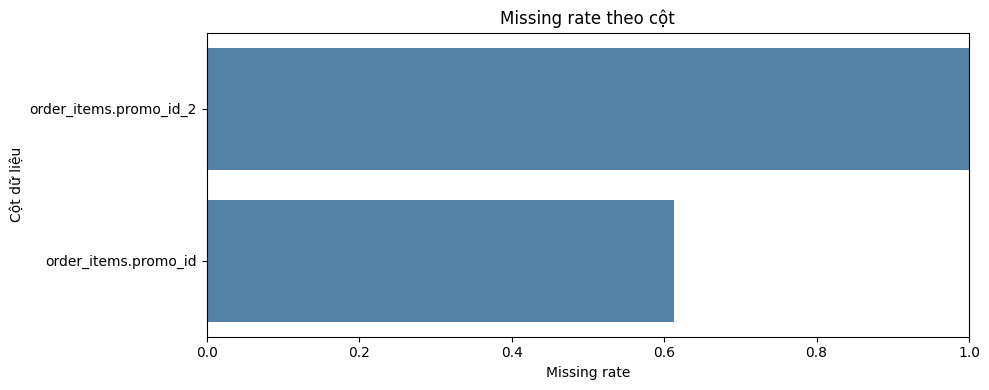

Saved: b:\DA_VSF\customer_churn_PL\report_10_6_2026\check_quality_outputs\figures\phase3_missing_rate_by_column.png


In [11]:
# Vẽ biểu đồ missing rate theo cột
if missing_plot_df.empty:
    print('Không có missing value để vẽ biểu đồ.')
else:
    plt.figure(figsize=(10, max(4, len(missing_plot_df) * 0.35)))
    sns.barplot(
        data=missing_plot_df,
        x='missing_rate',
        y='feature_name',
        color='steelblue'
    )

    plt.title('Missing rate theo cột')
    plt.xlabel('Missing rate')
    plt.ylabel('Cột dữ liệu')
    plt.xlim(0, 1)
    plt.tight_layout()

    output_path = FIGURE_DIR / 'phase3_missing_rate_by_column.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

## Kết luận Phase 3

- Hầu hết các cột **không thiếu dữ liệu** (0% missing) — đây là tín hiệu rất tốt cho dữ liệu thương mại điện tử.
- `order_items.promo_id` thiếu **~61.34%** → hơn nửa đơn hàng không dùng khuyến mãi. Đây là **missing có nghĩa** (*meaningful missing*), không phải lỗi.
- `order_items.promo_id_2` thiếu **~99.97%** → gần như rỗng hoàn toàn, không đủ thông tin để model học.

**Ý nghĩa DS:** Không phải cột thiếu nào cũng là lỗi. `promo_id = NaN` có nghĩa là đơn đó không dùng khuyến mãi — đây là thông tin có giá trị. Cần phân biệt: (1) missing do lỗi hệ thống, (2) missing vì giá trị thực sự không tồn tại.

**Cần làm tiếp ở bước clean data:**
- `promo_id`: cân nhắc **Loại**. Thực hiện loại bỏ vì bìa toán không xử dụng dữ liệu này.
- `promo_id_2`: Cân nhắc **loại hoàn toàn** — cột thiếu trên 95% thường không cung cấp đủ tín hiệu cho model.

## Phase 4 - Kiểm tra duplicate và key cơ bản

### Mục tiêu

- Kiểm tra duplicate toàn dòng trong từng bảng.
- Kiểm tra key chính hoặc key tổ hợp của từng bảng.
- Tạo bảng summary dễ đọc cho duplicate key.
- Vẽ biểu đồ duplicate key để thấy bảng nào có vấn đề.

In [12]:
# Kiểm tra duplicate toàn dòng
duplicate_rows = []

for table_name, df in tables.items():
    duplicate_count = int(df.duplicated().sum())
    duplicate_rate = duplicate_count / len(df) if len(df) > 0 else np.nan

    duplicate_rows.append({
        'table_name': table_name,
        'n_rows': len(df),
        'duplicate_full_rows': duplicate_count,
        'duplicate_rate': duplicate_rate,
    })

phase4_duplicate_summary = pd.DataFrame(duplicate_rows)
phase4_duplicate_summary.to_csv(TABLE_DIR / 'phase4_duplicate_summary.csv', index=False)

phase4_duplicate_summary

,table_name,n_rows,duplicate_full_rows,duplicate_rate
0,orders,646945,0,0.0
1,order_items,714669,0,0.0
2,customers,121930,0,0.0
3,products,2412,0,0.0
4,returns,39939,0,0.0
5,payments,646945,0,0.0


In [13]:
# Kiểm tra key cơ bản và duplicate key
key_rows = []

for table_name, keys in key_columns.items():
    if table_name not in tables:
        key_rows.append({
            'table_name': table_name,
            'key_columns': ', '.join(keys),
            'key_exists': False,
            'n_rows': np.nan,
            'unique_key_count': np.nan,
            'duplicate_key_rows': np.nan,
            'note': 'table_not_loaded',
        })
        continue

    df = tables[table_name]
    key_exists = all(col in df.columns for col in keys)

    if key_exists:
        duplicate_key_rows = int(df.duplicated(subset=keys).sum())
        unique_key_count = int(df[keys].drop_duplicates().shape[0])
        note = 'ok' if duplicate_key_rows == 0 else 'has_duplicate_key'
    else:
        duplicate_key_rows = np.nan
        unique_key_count = np.nan
        note = 'missing_key_column'

    key_rows.append({
        'table_name': table_name,
        'key_columns': ', '.join(keys),
        'key_exists': key_exists,
        'n_rows': len(df),
        'unique_key_count': unique_key_count,
        'duplicate_key_rows': duplicate_key_rows,
        'note': note,
    })

phase4_key_check = pd.DataFrame(key_rows)
phase4_key_check.to_csv(TABLE_DIR / 'phase4_key_check.csv', index=False)

phase4_key_check

,table_name,key_columns,key_exists,n_rows,unique_key_count,duplicate_key_rows,note
0,orders,order_id,True,646945,646945,0,ok
1,customers,customer_id,True,121930,121930,0,ok
2,products,product_id,True,2412,2412,0,ok
3,returns,return_id,True,39939,39939,0,ok
4,order_items,"order_id, product_id",True,714669,714653,16,has_duplicate_key
5,payments,order_id,True,646945,646945,0,ok


In [ ]:
# Vẽ biểu đồ duplicate key theo bảng
# Dùng trực tiếp kết quả từ cell kiểm tra key ngay phía trên: phase4_key_check

duplicate_key_plot_df = (
    phase4_key_check
    .loc[phase4_key_check["duplicate_key_rows"].fillna(0) > 0]
    .sort_values("duplicate_key_rows", ascending=False)
    .copy()
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=duplicate_key_plot_df,
    x="duplicate_key_rows",
    y="table_name",
    color="steelblue",
)

plt.title("Số dòng duplicate key theo bảng")
plt.xlabel("Duplicate key rows")
plt.ylabel("Tên bảng")
plt.tight_layout()

output_path = FIGURE_DIR / "phase4_duplicate_key_count_by_table.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)


## Kết luận Phase 4

- **Không có duplicate toàn dòng** trong cả 6 bảng — dữ liệu không bị export trùng.
- `orders`, `customers`, `products`, `returns`, `payments`: Key chính đều **duy nhất hoàn toàn** 
- `order_items` có **16 tổ hợp key `(order_id, product_id)` bị trùng**, ảnh hưởng **32 dòng** 

**Ý nghĩa DS:** Duplicate key trong `order_items` là vấn đề ngầm nguy hiểm. Khi ta aggregate (`groupby order_id → sum quantity`), 32 dòng trùng sẽ bị **tính hai lần** → feature bị sai số lượng và tổng tiền → model học sai. Không phải ai cũng phát hiện ra lỗi này trước khi train model.

**Cần làm tiếp ở bước clean data:**
- Xem 32 dòng trùng để hiểu nguyên nhân (lỗi nhập liệu? sản phẩm kèm gift? hệ thống insert hai lần?).
- Nếu là lỗi: xóa dòng trùng, chỉ giữ lại 1 dòng mỗi `(order_id, product_id)`.
- Nếu có lý do hợp lệ: điều chỉnh lại định nghĩa key hoặc aggregate thêm bước trung gian trước khi join.

## Phase 5 - Kiểm tra giá trị bất thường, outlier

### Mục tiêu

- Kiểm tra các cột số có giá trị âm, bằng 0 hoặc không đọc được thành số không.
- Kiểm tra khoảng min-max của các cột số để phát hiện giá trị quá lớn hoặc quá nhỏ.
- Kiểm tra số lượng nhóm unique của các cột danh mục.
- Vẽ biểu đồ cho các phần cần nhìn trực quan.

In [ ]:
# Kiểm tra giá trị số bất thường
numeric_columns_to_check = {
    'order_items': ['quantity', 'unit_price', 'discount_amount'],
    'products': ['price', 'cogs'],
    'returns': ['return_quantity', 'refund_amount'],
    'payments': ['payment_value', 'installments'],
}

numeric_rows = []

for table_name, cols in numeric_columns_to_check.items():
    if table_name not in tables:
        continue

    df = tables[table_name]
    for col in cols:
        if col not in df.columns:
            continue

        values = pd.to_numeric(df[col], errors='coerce')
        numeric_rows.append({
            'table_name': table_name,
            'column_name': col,
            'n_rows': len(df),
            'missing_or_not_number': int(values.isna().sum()),
            'negative_count': int((values < 0).sum()),
            'zero_count': int((values == 0).sum()),
            'min_value': values.min(),
            'max_value': values.max(),
            'mean_value': values.mean(),
        })

phase5_numeric_value_check = pd.DataFrame(numeric_rows)
phase5_numeric_value_check.to_csv(TABLE_DIR / 'phase5_numeric_value_check.csv', index=False)

phase5_numeric_value_check

In [ ]:
# Vẽ biểu đồ số lượng giá trị bằng 0 theo cột
zero_plot_df = phase5_numeric_value_check[
    phase5_numeric_value_check['zero_count'] > 0
].copy()

zero_plot_df['feature_name'] = (
    zero_plot_df['table_name'] + '.' + zero_plot_df['column_name']
)

if zero_plot_df.empty:
    print('Không có giá trị bằng 0 để vẽ biểu đồ.')
else:
    zero_plot_df = zero_plot_df.sort_values('zero_count', ascending=False)
    plt.figure(figsize=(8, max(3, len(zero_plot_df) * 0.4)))
    sns.barplot(data=zero_plot_df, x='zero_count', y='feature_name', color='steelblue')
    plt.title('Số lượng giá trị bằng 0 theo cột')
    plt.xlabel('Số dòng có giá trị bằng 0')
    plt.ylabel('Cột dữ liệu')
    plt.tight_layout()

    output_path = FIGURE_DIR / 'phase5_zero_count_by_column.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

In [ ]:
# Vẽ biểu đồ min-max của các cột số

range_plot_df = phase5_numeric_value_check.copy()

range_plot_df["feature_name"] = (
    range_plot_df["table_name"] + "." + range_plot_df["column_name"]
)

range_plot_df = range_plot_df.sort_values(
    "max_value",
    ascending=False
)

plt.figure(figsize=(10, max(4, len(range_plot_df) * 0.4)))

plt.hlines(
    y=range_plot_df["feature_name"],
    xmin=range_plot_df["min_value"],
    xmax=range_plot_df["max_value"],
    color="steelblue",
    linewidth=3
)

plt.scatter(
    range_plot_df["min_value"],
    range_plot_df["feature_name"],
    color="orange",
    label="Min"
)

plt.scatter(
    range_plot_df["max_value"],
    range_plot_df["feature_name"],
    color="green",
    label="Max"
)

plt.title("Khoảng giá trị min-max của các cột số")
plt.xlabel("Giá trị")
plt.ylabel("Cột dữ liệu")
plt.legend()
plt.tight_layout()

output_path = FIGURE_DIR / "phase5_numeric_min_max_range.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

In [ ]:
# Kiểm tra giá trị danh mục bất thường
category_columns_to_check = {
    'orders': ['order_status', 'payment_method', 'device_type', 'order_source'],
    'customers': ['city', 'gender', 'age_group', 'acquisition_channel'],
    'products': ['category', 'segment', 'size', 'color'],
    'returns': ['return_reason'],
    'payments': ['payment_method'],
}

category_rows = []

for table_name, cols in category_columns_to_check.items():
    if table_name not in tables:
        continue

    df = tables[table_name]
    for col in cols:
        if col not in df.columns:
            continue

        value_counts = df[col].value_counts(dropna=False)
        top_value = value_counts.index[0] if len(value_counts) > 0 else np.nan
        top_count = int(value_counts.iloc[0]) if len(value_counts) > 0 else 0

        category_rows.append({
            'table_name': table_name,
            'column_name': col,
            'n_rows': len(df),
            'unique_values': df[col].nunique(dropna=True),
            'top_value': top_value,
            'top_count': top_count,
            'top_rate': top_count / len(df) if len(df) > 0 else np.nan,
        })

phase5_category_value_check = pd.DataFrame(category_rows)
phase5_category_value_check.to_csv(TABLE_DIR / 'phase5_category_value_check.csv', index=False)

phase5_category_value_check

In [ ]:
# Vẽ biểu đồ số lượng unique value của cột danh mục
category_unique_plot_df = phase5_category_value_check.copy()
category_unique_plot_df['feature_name'] = (
    category_unique_plot_df['table_name'] + '.' + category_unique_plot_df['column_name']
)
category_unique_plot_df = category_unique_plot_df.sort_values('unique_values', ascending=False)

plt.figure(figsize=(10, max(4, len(category_unique_plot_df) * 0.4)))
sns.barplot(data=category_unique_plot_df, x='unique_values', y='feature_name', color='steelblue')
plt.title('Số lượng unique value của các cột danh mục')
plt.xlabel('Số lượng unique values')
plt.ylabel('Cột dữ liệu')
plt.tight_layout()

output_path = FIGURE_DIR / 'phase5_category_unique_values.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', output_path)

## Kết luận Phase 5

- **Không có giá trị âm** ở tất cả cột số đã kiểm tra (`quantity`, `unit_price`, `payment_value`, `refund_amount`...) 
- `discount_amount` có nhiều giá trị bằng 0 — **hoàn toàn hợp lý** vì nhiều đơn hàng không áp dụng discount.
- Các cột tiền (`payment_value`, `unit_price`, `refund_amount`) có **khoảng giá trị rộng** — cần EDA phân tích phân phối.
- Các cột danh mục đã có bảng thống kê unique/top value để chuẩn bị encode.

**Ý nghĩa DS:** Giá trị âm ở cột số lượng hoặc tiền thường là lỗi nghiêm trọng (không thể bán -3 sản phẩm). Khoảng giá trị rộng chưa phải lỗi, nhưng cần xử lý trước khi đưa vào các model tuyến tính (Logistic Regression cần chuẩn hóa — `StandardScaler`). XGBoost/Random Forest ít nhạy cảm hơn với scale của dữ liệu.

**Cần làm tiếp:**
- EDA: Vẽ histogram và boxplot cho cột tiền để phát hiện outlier cực đoan.
- Feature engineering: Cột danh mục nhiều nhóm (như `city`) cần dùng Target Encoding hoặc gom nhóm nhỏ thành `'Other'` thay vì One-Hot Encoding thuần túy.


## Phase 6 - Kiểm tra datetime có hợp lệ

### Mục tiêu

- Kiểm tra các cột ngày có parse được không.
- Kiểm tra min/max date để hiểu khoảng thời gian dữ liệu.
- Kiểm tra logic ngày đơn giản: return_date không được trước order_date.

In [ ]:
# Kiểm tra parse ngày tháng
date_columns_to_check = {
    'orders': ['order_date'],
    'customers': ['signup_date'],
    'returns': ['return_date'],
}

date_rows = []

for table_name, cols in date_columns_to_check.items():
    if table_name not in tables:
        continue

    df = tables[table_name]
    for col in cols:
        if col not in df.columns:
            continue

        parsed = pd.to_datetime(df[col], errors='coerce')
        date_rows.append({
            'table_name': table_name,
            'column_name': col,
            'n_rows': len(df),
            'parse_error_count': int(parsed.isna().sum()),
            'parse_error_rate': parsed.isna().mean(),
            'min_date': parsed.min(),
            'max_date': parsed.max(),
        })

phase6_date_parse_check = pd.DataFrame(date_rows)
phase6_date_parse_check.to_csv(TABLE_DIR / 'phase6_date_parse_check.csv', index=False)

phase6_date_parse_check

In [ ]:
# Kiểm tra logic ngày tháng đơn giản
date_logic_rows = []

if 'orders' in tables and 'returns' in tables:
    order_dates = tables['orders'][['order_id', 'order_date']].copy()
    return_dates = tables['returns'][['order_id', 'return_date']].copy()
    order_return_dates = return_dates.merge(order_dates, on='order_id', how='left')
    order_date = pd.to_datetime(order_return_dates['order_date'], errors='coerce')
    return_date = pd.to_datetime(order_return_dates['return_date'], errors='coerce')
    bad_order_return = int((return_date < order_date).sum())
    date_logic_rows.append({
        'check_name': 'return_date_before_order_date',
        'n_rows_checked': len(order_return_dates),
        'issue_count': bad_order_return,
        'issue_rate': bad_order_return / len(order_return_dates) if len(order_return_dates) > 0 else np.nan,
    })

phase6_date_logic_check = pd.DataFrame(date_logic_rows)
phase6_date_logic_check.to_csv(TABLE_DIR / 'phase6_date_logic_check.csv', index=False)

phase6_date_logic_check

## Kết luận Phase 6

- `order_date`, `signup_date`, `return_date` đều **parse được 100%** — không có giá trị ngày lỗi định dạng 
- Dữ liệu `orders` trải dài từ **2012-07-04 đến 2022-12-31** (10 năm lịch sử).
- **Không có `return_date` nào xảy ra trước `order_date`** — logic nghiệp vụ hợp lệ hoàn toàn 

**Ý nghĩa DS:** Dữ liệu ngày tháng hợp lệ cho phép ta tạo nhiều feature mạnh: số ngày từ khi đặt hàng, ngày trong tuần (weekend vs weekday), tháng/mùa trong năm, thời gian khách hàng đã gắn bó với shop (`order_date - signup_date`). Dữ liệu 10 năm cũng cho phép phân tích xu hướng theo năm.

**Cần làm tiếp ở feature engineering:**
- `order_month`, `order_day_of_week` — nắm bắt yếu tố mùa vụ (đơn cuối tuần hay dịp lễ có tỷ lệ trả hàng khác không?).
- `customer_tenure_days` = `order_date - signup_date` — khách hàng lâu năm có ít trả hàng hơn không?
- **Cảnh báo leakage:** `return_date` KHÔNG được dùng làm feature (xem Phase 10).


## Phase 7 - Kiểm tra quan hệ giữa các bảng

### Mục tiêu

- Kiểm tra các khóa liên kết giữa bảng con và bảng chính.
- Đảm bảo order_id, customer_id và product_id match được giữa các bảng cần dùng.
- Kiểm tra coverage của order trong order_items, returns và payments.

In [ ]:
# Kiểm tra foreign key giữa các bảng
foreign_key_checks = [
    ('order_items', 'order_id', 'orders', 'order_id'),
    ('returns', 'order_id', 'orders', 'order_id'),
    ('payments', 'order_id', 'orders', 'order_id'),
    ('orders', 'customer_id', 'customers', 'customer_id'),
    ('order_items', 'product_id', 'products', 'product_id'),
    ('returns', 'product_id', 'products', 'product_id'),
]

fk_rows = []

for child_table, child_key, parent_table, parent_key in foreign_key_checks:
    if child_table not in tables or parent_table not in tables:
        continue

    child_df = tables[child_table]
    parent_df = tables[parent_table]

    child_values = child_df[child_key].dropna()
    parent_values = set(parent_df[parent_key].dropna())
    not_match = ~child_values.isin(parent_values)
    not_match_count = int(not_match.sum())

    fk_rows.append({
        'child_table': child_table,
        'child_key': child_key,
        'parent_table': parent_table,
        'parent_key': parent_key,
        'n_rows_checked': len(child_values),
        'not_match_count': not_match_count,
        'not_match_rate': not_match_count / len(child_values) if len(child_values) > 0 else np.nan,
    })

phase7_foreign_key_check = pd.DataFrame(fk_rows)
phase7_foreign_key_check.to_csv(TABLE_DIR / 'phase7_foreign_key_check.csv', index=False)

phase7_foreign_key_check

In [ ]:
# Kiểm tra coverage order ở các bảng liên quan
coverage_rows = []

if 'orders' in tables:
    order_ids = set(tables['orders']['order_id'].dropna())

    for table_name in ['order_items', 'returns', 'payments']:
        if table_name not in tables or 'order_id' not in tables[table_name].columns:
            continue

        table_order_ids = set(tables[table_name]['order_id'].dropna())
        matched_order_count = len(order_ids.intersection(table_order_ids))

        coverage_rows.append({
            'table_name': table_name,
            'orders_total': len(order_ids),
            'orders_found_in_table': matched_order_count,
            'coverage_rate': matched_order_count / len(order_ids) if len(order_ids) > 0 else np.nan,
        })

phase7_order_coverage_check = pd.DataFrame(coverage_rows)
phase7_order_coverage_check.to_csv(TABLE_DIR / 'phase7_order_coverage_check.csv', index=False)

phase7_order_coverage_check

## Kết luận Phase 7

- **Tất cả foreign key được kiểm tra đều match 100%** — không có orphan record trong các bảng con.
- `order_items.order_id`, `returns.order_id`, `payments.order_id` đều tồn tại trong `orders.order_id`.
- `order_items.product_id` và `returns.product_id` đều tồn tại trong `products.product_id`.
- Coverage theo order cần đọc đúng ngữ cảnh:
  - `order_items` và `payments` cover 100% orders.
  - `returns` chỉ xuất hiện với nhóm đơn hoàn/trả, nên không kỳ vọng cover 100% toàn bộ orders.

**Ý nghĩa DS:** Phase này xác nhận các khóa join cơ bản an toàn. Tuy nhiên, riêng `returns` cần được kiểm tra thêm theo logic vòng đời ở Phase 8: order nào được coi là returned hợp lệ phải vừa có trạng thái phù hợp, vừa có bằng chứng trong bảng `returns`.

## Phase 8 - Kiểm tra lifecycle / chu trình đơn hàng

### Mục tiêu

- Kiểm tra logic vòng đời trước khi gắn nhãn binary.
- Xác nhận trạng thái `returned` có bằng chứng trong bảng `returns`.
- Xác nhận các đơn returned có đủ record liên quan trong `payments` và `order_items`.
- Kiểm tra các ràng buộc nghiệp vụ của bảng `returns`: sản phẩm trả có trong đơn, ngày trả không trước ngày đặt, số lượng trả không vượt số lượng mua.
- Phase này chỉ kiểm tra và ghi nhận conflict; chưa gắn nhãn model.

In [ ]:
# Tính phân bố order_status
phase8_order_status_distribution = (
    tables['orders']['order_status']
    .value_counts(dropna=False)
    .rename_axis('order_status')
    .reset_index(name='order_count')
)
phase8_order_status_distribution['order_rate'] = (
    phase8_order_status_distribution['order_count'] / len(tables['orders'])
)

phase8_order_status_distribution.to_csv(TABLE_DIR / 'phase8_order_status_distribution.csv', index=False)

phase8_order_status_distribution

In [ ]:
# Vẽ biểu đồ phân bố order_status
plt.figure(figsize=(8, 4))
sns.barplot(
    data=phase8_order_status_distribution,
    x='order_status',
    y='order_count',
    color='steelblue',
)
plt.title('Phân bố trạng thái đơn hàng')
plt.xlabel('order_status')
plt.ylabel('Số lượng order')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

output_path = FIGURE_DIR / 'phase8_order_status_distribution.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', output_path)

In [ ]:
# Chuẩn bị bảng lifecycle ở cấp order
orders_lifecycle = tables['orders'][['order_id', 'order_status', 'order_date']].copy()
returned_order_ids = set(tables['returns']['order_id'].dropna()) if 'returns' in tables else set()
payment_order_ids = set(tables['payments']['order_id'].dropna()) if 'payments' in tables else set()
item_order_ids = set(tables['order_items']['order_id'].dropna()) if 'order_items' in tables else set()

orders_lifecycle['has_return_record'] = orders_lifecycle['order_id'].isin(returned_order_ids)
orders_lifecycle['has_payment_record'] = orders_lifecycle['order_id'].isin(payment_order_ids)
orders_lifecycle['has_order_item_record'] = orders_lifecycle['order_id'].isin(item_order_ids)
orders_lifecycle['is_status_returned'] = orders_lifecycle['order_status'].eq('returned')
orders_lifecycle['is_status_delivered'] = orders_lifecycle['order_status'].eq('delivered')

orders_lifecycle.head()

In [ ]:
# Kiểm tra order_status = returned có record trong returns không
returned_status_check = pd.DataFrame([{
    'check_name': 'returned_status_orders',
    'order_count': int(orders_lifecycle['is_status_returned'].sum()),
}, {
    'check_name': 'returned_status_with_return_record',
    'order_count': int((orders_lifecycle['is_status_returned'] & orders_lifecycle['has_return_record']).sum()),
}, {
    'check_name': 'returned_status_missing_return_record',
    'order_count': int((orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_return_record']).sum()),
}])

returned_status_check

In [ ]:
# Kiểm tra record trong returns có thuộc order_status = returned không
returns_status_check = (
    tables['returns'][['order_id']]
    .drop_duplicates()
    .merge(tables['orders'][['order_id', 'order_status']], on='order_id', how='left')
)

returns_status_summary = (
    returns_status_check['order_status']
    .value_counts(dropna=False)
    .rename_axis('order_status')
    .reset_index(name='return_order_count')
)

returns_status_summary

In [ ]:
# Kiểm tra returned orders có payment và order_items không
returned_order_support_check = pd.DataFrame([{
    'check_name': 'returned_status_missing_payment_record',
    'issue_count': int((orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_payment_record']).sum()),
}, {
    'check_name': 'returned_status_missing_order_item_record',
    'issue_count': int((orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_order_item_record']).sum()),
}])

returned_order_support_check

In [ ]:
# Kiểm tra product_id và số lượng trong returns so với order_items
ordered_item_quantity = (
    tables['order_items']
    .groupby(['order_id', 'product_id'], as_index=False)['quantity']
    .sum()
    .rename(columns={'quantity': 'ordered_quantity'})
)

returns_item_check = (
    tables['returns']
    .merge(ordered_item_quantity, on=['order_id', 'product_id'], how='left')
)
returns_item_check['missing_order_product_pair'] = returns_item_check['ordered_quantity'].isna()
returns_item_check['return_quantity_gt_ordered_quantity'] = (
    returns_item_check['return_quantity'] > returns_item_check['ordered_quantity']
)

returns_item_summary = pd.DataFrame([{
    'check_name': 'return_order_product_missing_in_order_items',
    'issue_count': int(returns_item_check['missing_order_product_pair'].sum()),
}, {
    'check_name': 'return_quantity_greater_than_ordered_quantity',
    'issue_count': int(returns_item_check['return_quantity_gt_ordered_quantity'].sum()),
}])

returns_item_summary

In [ ]:
# Kiểm tra return_date không trước order_date
returns_date_check = (
    tables['returns'][['order_id', 'return_id', 'return_date']]
    .merge(tables['orders'][['order_id', 'order_date']], on='order_id', how='left')
)
returns_date_check['order_date'] = pd.to_datetime(returns_date_check['order_date'], errors='coerce')
returns_date_check['return_date'] = pd.to_datetime(returns_date_check['return_date'], errors='coerce')
returns_date_check['return_date_before_order_date'] = (
    returns_date_check['return_date'] < returns_date_check['order_date']
)

returns_date_summary = pd.DataFrame([{
    'check_name': 'return_date_before_order_date',
    'issue_count': int(returns_date_check['return_date_before_order_date'].sum()),
}])

returns_date_summary

In [ ]:
# Tổng hợp lifecycle summary và conflict details
lifecycle_summary_rows = [
    {
        'check_name': 'returned_status_missing_return_record',
        'issue_count': int((orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_return_record']).sum()),
        'severity': 'medium',
        'note': 'order_status returned nhưng không có order_id trong returns',
    },
    {
        'check_name': 'returns_record_without_returned_status',
        'issue_count': int((~returns_status_check['order_status'].eq('returned')).sum()),
        'severity': 'high',
        'note': 'có record returns nhưng order_status không phải returned',
    },
    {
        'check_name': 'returned_status_missing_payment_record',
        'issue_count': int(returned_order_support_check.loc[returned_order_support_check['check_name'].eq('returned_status_missing_payment_record'), 'issue_count'].iloc[0]),
        'severity': 'high',
        'note': 'order_status returned nhưng thiếu record payment',
    },
    {
        'check_name': 'returned_status_missing_order_item_record',
        'issue_count': int(returned_order_support_check.loc[returned_order_support_check['check_name'].eq('returned_status_missing_order_item_record'), 'issue_count'].iloc[0]),
        'severity': 'high',
        'note': 'order_status returned nhưng thiếu order_items',
    },
    {
        'check_name': 'return_order_product_missing_in_order_items',
        'issue_count': int(returns_item_check['missing_order_product_pair'].sum()),
        'severity': 'high',
        'note': 'returns.product_id không thuộc order_items của cùng order_id',
    },
    {
        'check_name': 'return_quantity_greater_than_ordered_quantity',
        'issue_count': int(returns_item_check['return_quantity_gt_ordered_quantity'].sum()),
        'severity': 'high',
        'note': 'return_quantity vượt quantity đã mua',
    },
    {
        'check_name': 'return_date_before_order_date',
        'issue_count': int(returns_date_check['return_date_before_order_date'].sum()),
        'severity': 'high',
        'note': 'return_date trước order_date',
    },
]

phase8_lifecycle_check_summary = pd.DataFrame(lifecycle_summary_rows)
phase8_lifecycle_check_summary['status'] = np.where(
    phase8_lifecycle_check_summary['issue_count'].eq(0),
    'pass',
    'review',
)
phase8_lifecycle_check_summary.to_csv(TABLE_DIR / 'phase8_lifecycle_check_summary.csv', index=False)

conflict_frames = []

missing_return_record = orders_lifecycle.loc[
    orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_return_record'],
    ['order_id', 'order_status']
].copy()
missing_return_record['conflict_type'] = 'returned_status_missing_return_record'
conflict_frames.append(missing_return_record)

returns_wrong_status = returns_status_check.loc[
    ~returns_status_check['order_status'].eq('returned'),
    ['order_id', 'order_status']
].copy()
returns_wrong_status['conflict_type'] = 'returns_record_without_returned_status'
conflict_frames.append(returns_wrong_status)

missing_payment = orders_lifecycle.loc[
    orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_payment_record'],
    ['order_id', 'order_status']
].copy()
missing_payment['conflict_type'] = 'returned_status_missing_payment_record'
conflict_frames.append(missing_payment)

missing_items = orders_lifecycle.loc[
    orders_lifecycle['is_status_returned'] & ~orders_lifecycle['has_order_item_record'],
    ['order_id', 'order_status']
].copy()
missing_items['conflict_type'] = 'returned_status_missing_order_item_record'
conflict_frames.append(missing_items)

missing_product_pair = returns_item_check.loc[
    returns_item_check['missing_order_product_pair'],
    ['order_id', 'product_id', 'return_id']
].copy()
missing_product_pair['conflict_type'] = 'return_order_product_missing_in_order_items'
conflict_frames.append(missing_product_pair)

quantity_conflict = returns_item_check.loc[
    returns_item_check['return_quantity_gt_ordered_quantity'],
    ['order_id', 'product_id', 'return_id', 'return_quantity', 'ordered_quantity']
].copy()
quantity_conflict['conflict_type'] = 'return_quantity_greater_than_ordered_quantity'
conflict_frames.append(quantity_conflict)

date_conflict = returns_date_check.loc[
    returns_date_check['return_date_before_order_date'],
    ['order_id', 'return_id', 'order_date', 'return_date']
].copy()
date_conflict['conflict_type'] = 'return_date_before_order_date'
conflict_frames.append(date_conflict)

phase8_lifecycle_conflict_details = pd.concat(conflict_frames, ignore_index=True, sort=False)
if phase8_lifecycle_conflict_details.empty:
    phase8_lifecycle_conflict_details = pd.DataFrame(columns=['conflict_type', 'order_id', 'order_status'])
else:
    cols = ['conflict_type'] + [c for c in phase8_lifecycle_conflict_details.columns if c != 'conflict_type']
    phase8_lifecycle_conflict_details = phase8_lifecycle_conflict_details[cols]
phase8_lifecycle_conflict_details.to_csv(TABLE_DIR / 'phase8_lifecycle_conflict_details.csv', index=False)

phase8_lifecycle_check_summary

In [ ]:
# Vẽ biểu đồ lifecycle consistency
lifecycle_plot_df = phase8_lifecycle_check_summary.copy()
lifecycle_plot_df['plot_label'] = lifecycle_plot_df['check_name'].str.replace('_', '\n')

plt.figure(figsize=(10, 5))
sns.barplot(
    data=lifecycle_plot_df,
    x='plot_label',
    y='issue_count',
    hue='status',
    dodge=False,
    palette={'pass': 'seagreen', 'review': 'tomato'},
)
plt.title('Lifecycle checks: số issue cần review')
plt.xlabel('Lifecycle check')
plt.ylabel('Issue count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status')
plt.tight_layout()

output_path = FIGURE_DIR / 'phase8_lifecycle_consistency.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', output_path)

## Kết luận Phase 8

- `order_status` có 6 trạng thái: `delivered`, `returned`, `cancelled`, `shipped`, `paid`, `created`.
- Có **36,142** orders mang trạng thái `returned`; trong đó **36,062** có record tương ứng trong `returns` và **80** thiếu record returns.
- Tất cả record trong `returns` đều thuộc order có `order_status = returned`; không có trường hợp bảng `returns` ghi nhận hoàn/trả cho đơn không mang trạng thái returned.
- Nhóm returned có đủ `payments` và `order_items`; không phát hiện thiếu record ở hai bảng này.
- Không phát hiện lỗi `return_date < order_date`, `return_quantity > ordered_quantity`, hoặc `returns.product_id` không nằm trong order_items của cùng order.
- 80 orders returned thiếu record returns được coi là **lifecycle conflict** mức medium: không dùng làm nhãn 1, nhưng vẫn giữ lại để audit dữ liệu vận hành.

**Ý nghĩa DS:** Phase này tách rõ hai việc thường bị lẫn: kiểm tra vòng đời dữ liệu và gắn nhãn model. Nếu bỏ qua kiểm tra lifecycle, mô hình có thể học từ nhãn sai hoặc từ các trạng thái chưa hoàn tất như `paid`, `shipped`, `created`. Quyết định cho Phase 9 là không xóa dòng khỏi notebook; chỉ các outcome hợp lệ mới nhận `0/1`, còn trạng thái chưa phải outcome binary hoặc conflict lifecycle sẽ giữ `returned_label = NaN`.

## Phase 9 - Tạo nhãn Returned/Delivered và kiểm tra cân bằng lớp

### Mục tiêu

- Gắn nhãn binary ở cấp order sau khi đã kiểm tra lifecycle.
- `returned_label = 1` nếu `order_status == returned` và có record trong `returns`.
- `returned_label = 0` nếu `order_status == delivered` và không có record trong `returns`.
- Các trạng thái khác hoặc conflict không bị xóa, nhưng giữ `returned_label = NaN` để không lẫn vào tập train binary.
- Tính phân phối nhãn trên tập có nhãn hợp lệ và thống kê riêng các dòng NaN.

In [ ]:
# Tạo returned_label nhưng giữ NaN cho trạng thái không thuộc binary outcome
orders_for_label = orders_lifecycle.copy()

valid_returned_mask = orders_for_label['is_status_returned'] & orders_for_label['has_return_record']
valid_delivered_mask = orders_for_label['is_status_delivered'] & ~orders_for_label['has_return_record']
delivered_conflict_mask = orders_for_label['is_status_delivered'] & orders_for_label['has_return_record']
returned_conflict_mask = orders_for_label['is_status_returned'] & ~orders_for_label['has_return_record']
other_status_mask = ~orders_for_label['order_status'].isin(['delivered', 'returned'])

orders_for_label['returned_label'] = np.select(
    [valid_returned_mask, valid_delivered_mask],
    [1, 0],
    default=np.nan,
)
orders_for_label['label_reason'] = np.select(
    [
        valid_returned_mask,
        valid_delivered_mask,
        delivered_conflict_mask,
        returned_conflict_mask,
        other_status_mask,
    ],
    [
        'valid_returned_status_with_return_record',
        'valid_delivered_without_return_record',
        'conflict_delivered_with_return_record',
        'conflict_returned_missing_return_record',
        'not_binary_outcome_status',
    ],
    default='unclassified_label_rule',
)

phase9_order_label_preview = orders_for_label.head(1000)
phase9_order_label_preview.to_csv(TABLE_DIR / 'phase9_order_label_preview.csv', index=False)

orders_for_label.head()

In [ ]:
# Tính phân phối nhãn trên tập có nhãn hợp lệ
labeled_orders_for_model = orders_for_label.loc[orders_for_label['returned_label'].notna()].copy()
labeled_orders_for_model['returned_label'] = labeled_orders_for_model['returned_label'].astype(int)

phase9_label_distribution = (
    labeled_orders_for_model['returned_label']
    .value_counts()
    .sort_index()
    .rename_axis('returned_label')
    .reset_index(name='order_count')
)
phase9_label_distribution['order_rate_in_labeled_set'] = (
    phase9_label_distribution['order_count'] / len(labeled_orders_for_model)
)
phase9_label_distribution['label_name'] = phase9_label_distribution['returned_label'].map({
    0: 'Delivered = 0',
    1: 'Returned = 1',
})
phase9_label_distribution.to_csv(TABLE_DIR / 'phase9_label_distribution.csv', index=False)

phase9_label_distribution

In [ ]:
# Thống kê các dòng giữ returned_label = NaN
phase9_label_exclusion_summary = (
    orders_for_label.loc[orders_for_label['returned_label'].isna()]
    .groupby(['label_reason', 'order_status'], dropna=False)
    .agg(order_count=('order_id', 'count'))
    .reset_index()
    .sort_values('order_count', ascending=False)
)
phase9_label_exclusion_summary['order_rate_in_all_orders'] = (
    phase9_label_exclusion_summary['order_count'] / len(orders_for_label)
)
phase9_label_exclusion_summary.to_csv(TABLE_DIR / 'phase9_label_exclusion_summary.csv', index=False)

phase9_label_exclusion_summary

In [ ]:
# Vẽ biểu đồ phân phối nhãn trên tập có nhãn hợp lệ
plt.figure(figsize=(7, 4))
sns.barplot(data=phase9_label_distribution, x='label_name', y='order_count', color='steelblue')
plt.title('Phân phối nhãn Returned/Delivered trên tập có nhãn hợp lệ')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng order')

for index, row in phase9_label_distribution.iterrows():
    plt.text(
        index,
        row['order_count'],
        f"{row['order_rate_in_labeled_set']:.2%}",
        ha='center',
        va='bottom',
    )

plt.tight_layout()

output_path = FIGURE_DIR / 'phase9_label_distribution.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', output_path)

## Kết luận Phase 9

- Không xóa dòng khỏi dữ liệu kiểm tra; các dòng không đủ điều kiện binary được giữ lại với `returned_label = NaN`.
- Tập có nhãn hợp lệ gồm **552,778** orders:
  - **Delivered = 0**: 516,716 orders.
  - **Returned = 1**: 36,062 orders.
- Tỷ lệ returned trên tập có nhãn hợp lệ là khoảng **6.52%**, khá là phù hợp với thực tế thường khoảng dưới 10% so với đơn delivered.
- Có **94,167** orders giữ `returned_label = NaN`: 94,087 orders ở trạng thái `created/paid/shipped/cancelled` và 80 orders `returned` nhưng thiếu record trong `returns`.
- Nhãn `NaN` không phải missing data thông thường; đây là quyết định nghiệp vụ để loại các trạng thái chưa đủ điều kiện khỏi bài toán binary mà vẫn giữ lại khả năng audit.

**Ý nghĩa DS:** Đây là bài toán mất cân bằng lớp mạnh. Nếu train model binary, cần lọc `returned_label.notna()` cho tập train/validation/test, đồng thời giữ bảng NaN để audit lifecycle và hiểu dữ liệu vận hành. Metric chính nên ưu tiên Recall/F1/PR-AUC cho lớp returned thay vì Accuracy.

## Phase 10 - Kiểm tra leakage risk

### Mục tiêu

- Liệt kê các cột không nên dùng làm feature vì chỉ biết sau khi đơn bị trả.
- Giúp tránh model học thông tin tương lai và cho kết quả tốt giả tạo.
- Phase này chỉ tạo bảng cảnh báo, chưa loại cột khỏi dữ liệu.

In [ ]:
# Lập bảng leakage risk
leakage_rows = [
    {'table_name': 'returns', 'column_name': 'return_date', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'chỉ biết sau khi đơn bị trả lại'},
    {'table_name': 'returns', 'column_name': 'return_reason', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'chỉ biết sau khi đơn bị trả lại'},
    {'table_name': 'returns', 'column_name': 'refund_amount', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'chỉ biết sau khi hoàn tiền'},
    {'table_name': 'returns', 'column_name': 'return_quantity', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'chỉ biết sau khi trả hàng'},
    {'table_name': 'orders', 'column_name': 'order_status', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'được dùng trực tiếp để xác định nhãn và vòng đời đơn'},
    {'table_name': 'derived', 'column_name': 'has_return_record', 'risk_level': 'high', 'use_as_feature': 'no', 'reason': 'được dùng trực tiếp để xác định nhãn returned'},
]

phase10_leakage_risk_table = pd.DataFrame(leakage_rows)
phase10_leakage_risk_table.to_csv(TABLE_DIR / 'phase10_leakage_risk_table.csv', index=False)

phase10_leakage_risk_table

## Kết luận Phase 10

- Các cột từ bảng `returns` như `return_date`, `return_reason`, `refund_amount`, `return_quantity` có leakage risk cao.
- `order_status` và biến dẫn xuất `has_return_record` không được dùng làm feature vì được dùng trực tiếp trong logic nhãn/lifecycle.
- Khi modeling, chỉ dùng thông tin có sẵn tại thời điểm đặt hàng hoặc trước đó; không dùng thông tin chỉ biết sau khi đơn đã hoàn/trả.

## Phase 11 - Tổng hợp issue

### Mục tiêu

- Gom các issue quan trọng từ các phase trước thành một bảng dễ đọc.
- Tạo action plan ngắn gọn để chuẩn bị cho clean data.
- Giúp người làm tiếp biết vấn đề nào cần xử lý trước modeling.

In [ ]:
# Tổng hợp issue log
issue_rows = []

for _, row in phase3_missing_value_summary.iterrows():
    if row['missing_level'] in ['medium', 'high']:
        issue_rows.append({
            'phase': 'Phase 3',
            'table_name': row['table_name'],
            'column_name': row['column_name'],
            'issue': 'missing_value',
            'issue_count': row['missing_count'],
            'severity': row['missing_level'],
            'suggested_action': 'xem lại ở bước clean data',
        })

for _, row in phase4_duplicate_summary.iterrows():
    if row['duplicate_full_rows'] > 0:
        issue_rows.append({
            'phase': 'Phase 4',
            'table_name': row['table_name'],
            'column_name': 'all_columns',
            'issue': 'duplicate_full_rows',
            'issue_count': row['duplicate_full_rows'],
            'severity': 'medium',
            'suggested_action': 'kiểm tra duplicate trước khi modeling',
        })

for _, row in phase4_key_check.iterrows():
    if row['note'] == 'has_duplicate_key':
        issue_rows.append({
            'phase': 'Phase 4',
            'table_name': row['table_name'],
            'column_name': row['key_columns'],
            'issue': 'duplicate_key',
            'issue_count': row['duplicate_key_rows'],
            'severity': 'medium',
            'suggested_action': 'kiểm tra grain của bảng',
        })

for _, row in phase5_numeric_value_check.iterrows():
    issue_count = int(row['negative_count'])
    if issue_count > 0:
        issue_rows.append({
            'phase': 'Phase 5',
            'table_name': row['table_name'],
            'column_name': row['column_name'],
            'issue': 'negative_value',
            'issue_count': issue_count,
            'severity': 'medium',
            'suggested_action': 'kiểm tra giá trị âm ở bước clean data',
        })

for _, row in phase6_date_parse_check.iterrows():
    if row['parse_error_count'] > 0:
        issue_rows.append({
            'phase': 'Phase 6',
            'table_name': row['table_name'],
            'column_name': row['column_name'],
            'issue': 'date_parse_error',
            'issue_count': row['parse_error_count'],
            'severity': 'medium',
            'suggested_action': 'kiểm tra định dạng ngày',
        })

for _, row in phase7_foreign_key_check.iterrows():
    if row['not_match_count'] > 0:
        issue_rows.append({
            'phase': 'Phase 7',
            'table_name': row['child_table'],
            'column_name': row['child_key'],
            'issue': 'foreign_key_not_match',
            'issue_count': row['not_match_count'],
            'severity': 'medium',
            'suggested_action': 'kiểm tra dữ liệu không match khi join',
        })

for _, row in phase8_lifecycle_check_summary.iterrows():
    if row['issue_count'] > 0:
        issue_rows.append({
            'phase': 'Phase 8',
            'table_name': 'orders/returns',
            'column_name': 'order_id',
            'issue': row['check_name'],
            'issue_count': row['issue_count'],
            'severity': row['severity'],
            'suggested_action': 'review conflict lifecycle trước khi modeling',
        })

phase11_quality_issue_log = pd.DataFrame(issue_rows)
phase11_quality_issue_log.to_csv(TABLE_DIR / 'phase11_quality_issue_log.csv', index=False)

phase11_quality_issue_log

In [ ]:
# Tạo action plan đơn giản
if phase11_quality_issue_log.empty:
    phase11_quality_action_plan = pd.DataFrame([{
        'priority': 'normal',
        'action': 'có thể chuyển sang EDA',
        'note': 'chưa thấy issue lớn trong các kiểm tra cơ bản',
    }])
else:
    phase11_quality_action_plan = (
        phase11_quality_issue_log
        .groupby(['severity', 'issue', 'suggested_action'], dropna=False)
        .agg(total_issue_count=('issue_count', 'sum'))
        .reset_index()
        .sort_values(['severity', 'total_issue_count'], ascending=[True, False])
    )

phase11_quality_action_plan.to_csv(TABLE_DIR / 'phase11_quality_action_plan.csv', index=False)

phase11_quality_action_plan

In [ ]:
# Vẽ biểu đồ issue theo mức độ nghiêm trọng
if phase11_quality_issue_log.empty:
    print('Không có issue để vẽ biểu đồ.')
else:
    issue_severity_plot_df = (
        phase11_quality_issue_log
        .groupby('severity', as_index=False)
        .agg(issue_count=('issue', 'count'))
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=issue_severity_plot_df, x='severity', y='issue_count', color='steelblue')
    plt.title('Số lượng issue theo mức độ nghiêm trọng')
    plt.xlabel('Mức độ')
    plt.ylabel('Số issue')
    plt.tight_layout()

    output_path = FIGURE_DIR / 'phase11_issue_count_by_severity.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print('Saved:', output_path)

## Kết luận Phase 11

- Issue log hiện ghi nhận các vấn đề cần xử lý trước modeling: missing `promo_id`, `promo_id_2`, duplicate key trong `order_items`, và 80 conflict lifecycle `returned` nhưng thiếu record trong `returns`.
- Các lỗi nghiêm trọng về foreign key, date parse, ngày trả trước ngày đặt, sản phẩm trả không thuộc đơn, hoặc số lượng trả vượt số lượng mua đều không xuất hiện.
- Action plan cần ưu tiên xử lý feature khuyến mãi, duplicate order_items, và quyết định nghiệp vụ cho 80 orders returned thiếu record returns.

## Phase 12 - Kết luận quality check

### Mục tiêu

- Tóm tắt toàn bộ kết quả quality check.
- Kết luận dữ liệu đã đủ điều kiện chuyển sang EDA/clean data chưa.
- Ghi rõ next step cho người làm tiếp.

In [ ]:
# Tóm tắt kết quả quality check
high_issue_count = int((phase11_quality_issue_log['severity'] == 'high').sum()) if not phase11_quality_issue_log.empty else 0
medium_issue_count = int((phase11_quality_issue_log['severity'] == 'medium').sum()) if not phase11_quality_issue_log.empty else 0

phase12_quality_check_summary = pd.DataFrame([{
    'tables_loaded': len(tables),
    'output_tables_created': len(list(TABLE_DIR.glob('*.csv'))),
    'high_issue_count': high_issue_count,
    'medium_issue_count': medium_issue_count,
    'labeled_order_count': int(orders_for_label['returned_label'].notna().sum()),
    'unlabeled_order_count': int(orders_for_label['returned_label'].isna().sum()),
    'ready_for_eda': True,
    'ready_for_modeling': high_issue_count == 0,
}])

phase12_quality_check_summary.to_csv(TABLE_DIR / 'phase12_quality_check_summary.csv', index=False)

phase12_quality_check_summary

In [ ]:
# Viết kết luận cuối
if high_issue_count == 0:
    conclusion = 'Dữ liệu có thể chuyển sang EDA và chuẩn bị modeling sau khi clean data cơ bản.'
else:
    conclusion = 'Dữ liệu có thể chuyển sang EDA, nhưng chưa nên modeling ngay vì còn issue high cần xử lý.'

phase12_quality_check_conclusion = pd.DataFrame([{
    'conclusion': conclusion,
    'next_step': 'Dùng returned_label 0/1 cho tập có nhãn; giữ các dòng returned_label NaN để audit lifecycle, xử lý promo_id/promo_id_2 và duplicate key trước modeling.',
}])

phase12_quality_check_conclusion.to_csv(TABLE_DIR / 'phase12_quality_check_conclusion.csv', index=False)

phase12_quality_check_conclusion

## Kết luận Phase 12

**Dữ liệu có thể chuyển sang EDA** nhưng **chưa nên modeling trực tiếp** nếu chưa xử lý các issue đã ghi trong Phase 11.

**Tổng kết những gì đã xác nhận:**
- 6 bảng đều load được, schema đầy đủ, không thiếu cột.
- Foreign key cơ bản khớp 100%, có thể join an toàn.
- Ngày tháng hợp lệ, không có lỗi logic ngày trả trước ngày đặt.
- Không có giá trị âm ở cột số.
- Lifecycle returned nhìn chung nhất quán: returns khớp status returned, có payment và order_items đầy đủ.
- Có 80 orders `returned` thiếu record trong `returns`; các dòng này giữ `returned_label = NaN` để không làm nhiễu bài toán binary.
- Nhãn binary hợp lệ gồm 516,716 delivered và 36,062 returned; các trạng thái khác giữ NaN.
- Leakage risk đã được xác định và blacklist.
- `promo_id`, `promo_id_2`, duplicate key trong `order_items`, và 80 conflict lifecycle cần được xử lý/ghi chú trước modeling.

**Lộ trình tiếp theo:**
```
Clean Data  ->  EDA  ->  Feature Engineering  ->  Modeling
```

**Nguyên tắc quan trọng:** Khi train model binary, dùng `returned_label.notna()` để chọn tập có nhãn hợp lệ; không tự động biến `created/paid/shipped/cancelled` thành returned.